# Data preprocessing

We are going to start Preprocessing the data from the "liar" dataset in order to make it ready for the model, while following the README.md file.

Below we will import all required modules for this notebook:

In [ ]:
import pandas as pd
import numpy as np
import pickle
import time
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_validate, train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_predict, train_test_split

from xgboost import XGBClassifier

from rapidfuzz import process

from langchain_google_genai import ChatGoogleGenerativeAI
from langsmith import Client
from langchain_chroma import Chroma
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.documents import Document

from IPython.display import Markdown


## Importing Liar Data (TEST + TRAIN + VAL together)

In [42]:
# In the "liar" dataset, we know the columns are ordered as follows:
columns = [
    'id',
    'label',
    'statement',
    'subject',
    'speaker',
    'job_title',
    'state',
    'party',
    'barely_true_counts',
    'false_counts',
    'half_true_counts',
    'mostly_true_counts',
    'pants_on_fire_counts',
    'context'
]

df_l_train = pd.DataFrame(pd.read_csv('/home/mnavarrosotes/code/navaso93/final_project/liar_project/raw_data/liar/train.tsv', sep='\t', header=None, names=columns))
df_l_test = pd.DataFrame(pd.read_csv('/home/mnavarrosotes/code/navaso93/final_project/liar_project/raw_data/liar/test.tsv', sep='\t', header=None, names=columns))
df_l_val = pd.DataFrame(pd.read_csv('/home/mnavarrosotes/code/navaso93/final_project/liar_project/raw_data/liar/valid.tsv', sep='\t', header=None, names=columns))

### Importing Politifact data

In [ ]:
# Reading JSON file considering trailing lines
df_pol = pd.read_json("/home/mnavarrosotes/code/navaso93/final_project/liar_project/raw_data/politifact/politifact_factcheck_data.json", lines=True)

### Concatenating Politifact + LIAR data, and simplifying result

In [5]:
def dataset_merger(liar_df_train, liar_df_test, liar_df_val, politifact_df):

    # LIAR DATASET:
    # Concatenating TRAIN, TEST and VALIDATION datasets:
    df_l_tt = pd.concat([liar_df_train, liar_df_test], ignore_index=True)
    df_l = pd.concat([df_l_tt, liar_df_val], ignore_index=True)

    # POLITIFACT DATASET:
    # Replacing different label values to match those of LIAR dataset
    politifact_df["verdict"] = politifact_df["verdict"].replace({'mostly-false': 'barely-true'})

    # Renaming columns to match those names in LIAR dataset
    df_pol = politifact_df.rename(columns={'verdict':'label','statement_originator':'speaker', 'statement_source':'context'})
    df_pol = df_pol[["label", "speaker","statement","context"]]

    # Concatenating LIAR & POLITIFACT datasets
    df_dataset = pd.concat([df_l, df_pol], axis=0, ignore_index=True)

    # We choose only columns available in both. Better for model training and especially predictions.
    df_dataset = df_dataset[["label", "speaker","statement","context"]]

    # We have observed some statements are duplicated (appearing in both LIAR & Politifact datasets). We will remove duplicated statements from the same speaker:
    df_dataset["statement"] = df_dataset["statement"].str.lower().str.strip().str.split().str.join(" ")
    df_dataset = df_dataset.drop_duplicates(subset=["statement", "speaker"])

    return df_dataset


## Text Preprocessing

As mentionned in the README.md file, we will apply the following sequence to all text features:
- **strip:** Removes all whitespaces at the beginning anfd the end of a string. You can also specify a list of characters to be removed at the beginning and end of a string (RECOMMENDED)
- **replace:** Can be used to replace some words by another.
- **split:** Used to split a text into a lsit, where each word is an item.
- **numbers:** Numbers should be removed during text preprocessing steps.
- **punctuation and symbols:** Punctuation and other symbols should be removed for text preprocessing.

In [7]:
def df_text_preprocessing(df):
    """
    Reformats all text in the dataset.
    Concatenates speaker and statement column, so we end up having "speaker + statement" into the "statement" column.
    This prevents us having to encode speaker later, while still getting its information.
    """

    # We remove "id" column
    if "id" in df.columns:
        df = df.drop(columns="id")

    # We define columns
    text_col = [
        'statement',
        'subject',
        'speaker',
        'job_title',
        'state',
        'party',
        'context'
    ]

    # Iterate through each column applying text preprocessing methods
    for col in text_col:
        if col in df.columns:
            df[col] = (
                df[col]
                .fillna("")
                .astype(str)
                .str.lower()
                .str.strip()
                .str.replace(r"\d+", "", regex=True) # We replace numbers by empty values
                .str.replace(r"[^\w\s]", " ", regex=True) # We replace punctuation by blank spaces, since it might separate two words.
            )

    # We concatenate the strings in "speaker" and "statement"
    df["statement"] = df["speaker"] + " " +  df["statement"]

    # We drop the "speaker" column as it is reduncdant for training the models (we will not OneHotEncode it)
    df = df.drop(columns="speaker")


    return df


### Specific column fixes

#### State

Some state names are differently typed for the same state (we have 84 different states!!!), or have other issues that cause the model to loose context. We should cluster the state names only into the valid names:

In [8]:
# Function that finds the closest valid state name
def correct_state(state):

    valid_states = [
        "alabama", "alaska", "arizona", "arkansas", "california", "colorado", "connecticut", "delaware", "florida",
        "georgia", "hawaii", "idaho", "illinois", "indiana", "iowa", "kansas", "kentucky",
        "louisiana", "maine", "maryland", "massachusetts", "michigan", "minnesota", "mississippi", "missouri",
        "montana", "nebraska", "nevada", "new hampshire", "new jersey",
        "new mexico", "new york", "north carolina", "north dakota", "ohio",
        "oklahoma", "oregon", "pennsylvania", "rhode island", "south carolina",
        "south dakota", "tennessee", "texas", "utah", "vermont",
        "virginia", "washington", "west virginia", "wisconsin", "wyoming"
    ]
    # Handle missing values
    if pd.isna(state):
        return "unknown"

    # Convert to lowercase and remove spaces around the test
    state = str(state).lower().strip()

    # Find the closest match from the valid states list
    match, score, _ = process.extractOne(state, valid_states)

    # Only replace if similarity is high enough
    # We will be flexible and apply a similarity threshold of 75%
    if score >= 80:
        return match

    # Otherwise keep original value
    return state

#### Job Title

The values in the Job Title column are too scattered and non uniform. This prevents the model from gaining important context for the predictions.
We are going to try and cluster all the values into a smaller group:

In [9]:
def simplify_job_title(title):

    if pd.isna(title):
        return "unknown"

    if title in ["president", "president elect", "presidential candidate", "former president"]:
        return "president"

    elif "governor" in title:
        return "governor"

    elif "senator" in title:
        return "senator"

    elif "legislator" in title:
        return "legislator"

    elif 'mayor' in title:
        return 'mayor'

    elif 'ambassador' in title:
        return 'ambassador'

    elif any(x in title for x in ["representative", "congressman", "congresswoman", "house"]):
        return "representative"

    elif "attorney" in title or "lawyer" in title:
        return "legal"

    elif any(x in title for x in ["radio host", "host", "journalist", "reporter", "blog", 'social', 'columnist']):
        return "media"

    elif any(x in title for x in ['president', 'ceo', 'director', 'founder', 'business']):
        return 'private executive'

    elif "candidate" in title:
        return "candidate"

    else:
        return "other"

#### Context

In [10]:
# Function to simplify context values into broader categories
def simplify_context(context):

    # Handle missing values
    if pd.isna(context):
        return "unknown"

    # Convert to Lowercase for consistent matching
    context = str(context).lower()

    # Ads and commercials
    if any(x in context for x in ["ad", "commercial", "mailer"]):
        return "ad"

    # Interviews
    elif "interview" in context:
        return "interview"

    # Speeches and remarks
    elif any(x in context for x in ["press release", "news release"]):
        return "press release"

    # Press and news conferences
    elif any(x in context for x in ["press conference", "news conference"]):
        return "news conference"

    # Debates
    elif "debate" in context:
        return "debate"

    # Social media and websites
    elif any(x in context for x in ["tweet", "facebook", "website", "social"]):
        return "social media"

    # Statements
    elif "statement" in context:
        return "statement"

    # Emails
    elif any(x in context for x in ["email", " e mail", "chain mail"]):
        return "email"

    # TV appearances
    elif any(x in context for x in ["television", "tv", "fox news", "cnn", "meet the press"]):
        return "tv appearance"

    # Everything else
    else:
        return "other"

#### Party

In [11]:
# Function to simplify party affiliations into 5 broad categories
def simplify_party(party):

    # Handle missing values
    if pd.isna(party):
        return "unknown"

    # Convert to lowercase for consistent matching
    party = str(party).lower()

    # Republicans and related groups
    if any(x in party for x in ["republican", "tea party"]):
        return "republican"

    # Democrats and related groups
    elif any(x in party for x in ["democrat", "democratic farmer labor"]):
        return "democrat"

    # Other political parties
    elif any(x in party for x in ["independent", "libertarian", "green", "constitution party", "moderate"]):
        return "other_party"

    # Non-party entities, professions and organizations
    elif any(x in party for x in ["organization", "journalist", "columnist", "newsmaker", "activist", "talk show host", "state official", "education official",
        "government body", "business leader", "labor leader", "commissioner"]):
        return "organization"

    # Missing or unknown affiliation
    elif party == "none":
        return "unknown"

    # Catch any remaining rare values
    else:
        return "other"

#### Subject

There are initially 4144 different subjects. This is an excessively high number, especially considering that lots of them are the same, but written diffrently. We will try to cluster the main categories to avoid repetition under different wording.

In [12]:
# Function to simplify subjects into broader topic groups
def simplify_subject(subject):

    # Handle missing values
    if pd.isna(subject):
        return "unknown"

    # Convert to lowercase for consistent matching
    subject = str(subject).lower()

    # Health
    if any(x in subject for x in ["health", "medicare", "medicaid", "hospital", "disease", "ebola"]):
        return "health"

    # Economy and jobs
    elif any(x in subject for x in ["economy", "job", "worker", "small business", "income"]):
        return "economy"

    # Taxation
    elif "tax" in subject:
        return "taxation"

    # Budget and finance
    elif any(x in subject for x in ["budget", "finance", "deficit", "debt"]):
        return "budget"

    # Education
    elif "education" in subject:
        return "education"

    # Immigration
    elif any(x in subject for x in ["immigration", "border", "refugee"]):
        return "immigration"

    # Elections and campaigns
    elif any(x in subject for x in ["election", "candidate biography", "campaign", "voting record"]):
        return "elections"

    # Security and crime
    elif any(x in subject for x in ["crime", "criminal justice", "terrorism", "gun", "public safety"]):
        return "security"

    # Foreign affairs
    elif any(x in subject for x in ["foreign policy", "iraq", "afghanistan", "china", "israel", "trade"]):
        return "foreign affairs"

    # Environment and climate
    elif any(x in subject for x in ["environment", "climate", "weather"]):
        return "environment"

    # Energy
    elif "energy" in subject:
        return "energy"

    # Transportation
    elif "transportation" in subject:
        return "transportation"

    # Military and veterans
    elif any(x in subject for x in ["military", "veteran", "defense"]):
        return "military"

    # Government and politics
    elif any(x in subject for x in ["government", "ethic", "legal issue", "congress"]):
        return "government"

    # Social issues
    elif any(x in subject for x in ["abortion", "religion", "gay", "lesbian", "woman", "queer", "marriage"]):
        return "social issues"

    # Science and technology
    elif any(x in subject for x in ["science", "technology", "research"]):
        return "science"

    # Everything else
    else:
        return "other"

#### Label

The label ahs currently 6 categories,a nd for the model to properly distinguish between e.g. a "partly-true" statement and a "mostly-true" statement, it can be hard (it is even for humans!). 
We will cluster the label into 3 categories:

In [13]:
def simplify_label(label):

    # Already simplified -> leave unchanged
    if label in ["trustworthy", "questionable", "unreliable"]:
        return label

    if label in ["true", "mostly-true", "mostly true"]:
        return "trustworthy"

    elif label in ["half-true", "half true"]:
        return "questionable"

    else:
        return "unreliable"

#### Speaker truthfulness score

As there are some NaN values in the counter of statement truthfulness for each speaker, we will remove them and assume them as zero. This will allow us to later use the ColumnTransformer.

In [14]:
def fill_speaker_history(df):

    score_cols = [
        "barely_true_counts",
        "false_counts",
        "half_true_counts",
        "mostly_true_counts",
        "pants_on_fire_counts"
    ]
    for col in score_cols:
        if col in df.columns:
            df[score_cols] = df[score_cols].fillna(0)
    return df

### We apply ALL data preprocessing

In [15]:
def full_preprocessing(df):

    if "label" in df.columns:
        df["label"] = df["label"].apply(simplify_label) # First we cluster label categories

    df = df_text_preprocessing(df) # Then we apply all preprocessing methods

    if "state" in df.columns:
        df["state"] = df["state"].apply(correct_state) # We cluster state column as per function

    if "job_title" in df.columns:
        df["job_title"] = df["job_title"].apply(simplify_job_title) # We cluster job_title column as per function

    if "context" in df.columns:
        df["context"] = df["context"].apply(simplify_context) # We cluster context column as per function

    if "party" in df.columns:
        df["party"] = df["party"].apply(simplify_party) # We cluster party column as per function

    if "subject" in df.columns:
        df["subject"] = df["subject"].apply(simplify_subject) # We cluster subject column as per function

    df = fill_speaker_history(df) # We clean speaker history column form NaN and fill with 0

    return df


## Tokenizing

In [16]:
def tokenizer(df):

    # We define which columns we want to tokenize
    col_tk = ['statement',
              'subject',
              'job_title',
              'state',
              'context']

    for col in col_tk:
        if col in df.columns:
            df[col] = df[col].fillna("").apply(word_tokenize)

    return df

## Stopwords

In [17]:
def rm_stopwords(df):

    # Define list of stopwords
    stop_words = set(stopwords.words('english'))

    # Iterate through dataframe columns to remove stopwords
    col_tk = ['statement', 'subject', 'job_title', 'state', 'context']

    for col in col_tk:
        if col in df.columns:
            df[col] = df[col].apply(lambda tokens: [w for w in tokens if w not in stop_words])

    return df


## Lemmatize

In [18]:
def lemmatizer(df):

    # We instantiate lemmatizer and columns to lemmatize
    lemmatizer = WordNetLemmatizer()
    col_lm = ['statement', 'subject', 'job_title', 'state', 'context']

    # We lemmatize the columns
    for col in col_lm:
        if col in df.columns:
            df[col] = df[col].apply(lambda tokens: [WordNetLemmatizer().lemmatize(w) for w in tokens])

    return df

# Reformatting to string before Vectorizing

First, columns, need to be put back as a string, not a list.

In [19]:
def df_stringifier(df):

    # We define columns to vectorize
    col_vc = ['statement', 'subject', 'job_title', 'state', 'context']

    # We reformat tokenized columns back to strings (not lists) to prepare for vectorization
    for col in col_vc:
        if col in df.columns:
            df[col] = df[col].apply(lambda token: " ".join(token))

    return df

# Vectorizing + Testing model (Naive Bayes) 

### Train Test Split

In [20]:
def split_data(df):

    y = df["label"]
    X = df.drop(columns=["label"])

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    return X_train, X_test, y_train, y_test, y_train.value_counts(normalize=True)

In [21]:
def train_naive_bayes(X_train, y_train):
    # Initializing preprocessor
    preprocessor = ColumnTransformer(
        transformers = [
            ("statement", TfidfVectorizer(max_df=0.9, min_df=1, ngram_range=(1, 3)), "statement"),
            #("subject", OneHotEncoder(handle_unknown="ignore"), ["subject"]),
            ("context", OneHotEncoder(handle_unknown="ignore"), ["context"])#,
            #("job_title", OneHotEncoder(handle_unknown="ignore"), ["job_title"]),
            #("party", OneHotEncoder(handle_unknown="ignore"), ["party"]),
            #("state", OneHotEncoder(handle_unknown="ignore"), ["state"]),
            #("speaker_history", "passthrough", ["barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts"])
        ]
    )

    # Pipeline vectorizer + Naive Bayes
    pipeline_nb = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", MultinomialNB(alpha=0.1))]
    )

    # We will create probability of a statement being unreliable by using different folds in the dataset
    probas = cross_val_predict(
        pipeline_nb,
        X_train,
        y_train,
        cv=5,
        method="predict_proba", # Creates probabilities of each label to be correct
        n_jobs=-1
    )

    # Training model on all data
    pipeline_nb.fit(X_train, y_train)

    # We define unrel_proba (probability of statement being unreliable)
    unrel_proba = pd.DataFrame(
        probas[:, 2],
        columns=["unrel_proba"],
        index=X_train.index
    )

    return pipeline_nb, unrel_proba

In [22]:
def gridsearch_nb(pipeline_nb, df):

    X = df.drop(columns="label")
    y = df["label"]

    # Fine tuning with GridSearchCV
    # Train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.11, random_state=1)

    # Hyperparameter Grid
    grid = {
        "preprocessor__statement__ngram_range": [(1,1), (1,2)],
        "preprocessor__statement__min_df": [1, 5],
        "preprocessor__statement__max_df": [0.9, 0.95],
        "classifier__alpha": [0.1, 1, 10]
    }

    search_grid = GridSearchCV(
        pipeline_nb,
        grid,
        scoring= ['accuracy'], #{'recall': 'recall_macro', 'f1': 'f1_macro'},
        cv=5,
        n_jobs=-1, # parallelize computation,
        refit='accuracy'
    )

    search_grid.fit(X_train, y_train)

    return search_grid.best_params_, search_grid.best_score_

In [23]:
#def gridsearch(pipeline_xgb, df):

# grid_xg = [
#     {
#         "classifier__n_estimators": [100, 300, 500],
#         "classifier__max_depth": [3, 6, 10],
#         "classifier__learning_rate": [0.01, 0.1, 0.3],
#         "classifier__subsample": [0.8, 1.0]
#     }
# ]

# search_grid_A_xg = GridSearchCV(
#     pipeline_A_xg,
#     grid_xg,
#     scoring= ['accuracy'], #{'recall': 'recall_macro', 'f1': 'f1_macro'},
#     cv=5,
#     n_jobs=-1, # parallelize computation,
#     refit='accuracy'
# )

# search_grid_A_xg.fit(X_A_train, y_A_train_e)

# print("SearchGrid best_score: ", search_grid_A_xg.best_score_)
# print("SearchGrid best_params: ", search_grid_A_xg.best_params_)

## On top of Naive Bayes we will use XGBoost
### After adding 'unrel_proba' as a feature

In [24]:
def train_xg_boost(X_train, y_train, unrel_proba):

    # Create features and target and 'statement' column to avoid redundancy with unrel_proba, as well as excessive computaitonal cost
    X_train_ns = X_train.drop(columns=["statement"])

    # Appending 'unrel_proba' to features table
    X_extended = pd.concat([X_train_ns, unrel_proba], axis=1)

    # Preprocessing all columns
    preprocessor_xgb = ColumnTransformer(
        transformers = [
            #("subject", OneHotEncoder(handle_unknown="ignore"), ["subject"]),
            ("context", OneHotEncoder(handle_unknown="ignore"), ["context"]),
            #("job_title", OneHotEncoder(handle_unknown="ignore"), ["job_title"]),
            #("party", OneHotEncoder(handle_unknown="ignore"), ["party"]),
            #("state", OneHotEncoder(handle_unknown="ignore"), ["state"]),
            #("speaker_history", "passthrough", ["barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts"]),
            ("unrel_proba", "passthrough", ["unrel_proba"])
        ]
    )

    # Instantiating pipeline
    pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor_xgb),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.3,
        subsample=0.1,
        colsample_bytree=0.8,
        random_state=42
        ))
    ])

    # Applying label encoder for XGBoost
    le = LabelEncoder()
    y_e = le.fit_transform(y_train)


    # Fitting pipeline with train data
    pipeline_xgb.fit(X_extended, y_e)

    return pipeline_xgb, le # Returns the trained pipeline_xgb to be used in another predict function AND the Label Encoder object

In [25]:
def liar_predict(pipeline_nb, pipeline_xgb, le, X_predict):

    # We handle NaN values in X_predict, since NB can not predict if there are NaN values
    # We map NaN values to same values the models were trained on: "unknown" and 0 for numerical columns

    # Possible columns and default values (if NaN) mapping
    possible_cols = ["statement","subject","speaker","job_title","state","party","context","false_counts","half_true_counts","barely_true_counts","pants_on_fire_counts","mostly_true_counts"]
    default_values = ["unknown", "unknown", "unknown", "unknown", "unknown", "unknown", "unknown", 0, 0, 0, 0, 0]
    X_actual = {}

    for c, v in zip(possible_cols, default_values):
        if c in X_predict.columns:
            X_actual[c] = v

    X_predict_n = X_predict.fillna(X_actual)

    # Before editing X_extended we predict with Naive Bayes for better overview
    pred_nb = pipeline_nb.predict(X_predict_n)
    probas_nb = pipeline_nb.predict_proba(X_predict_n)

    # Extract predicted probability of statement being unreliable, based on trained Naive Bayes model
    unrel_proba = pd.DataFrame(pipeline_nb.predict_proba(X_predict_n)[:, 2], columns=["unrel_proba"])

    # Append feature
    X_extended = pd.concat([X_predict_n, unrel_proba], axis=1)

    # Drop 'statement' from X_extended
    X_extended = X_extended.drop(columns="statement")

    pred_xgb_coded = pipeline_xgb.predict(X_extended)
    probas_xgb = pipeline_xgb.predict_proba(X_extended)

    # Decode labels
    pred_xgb = le.inverse_transform(pred_xgb_coded)

    return {
        "pred_nb": pred_nb,
        "probas_nb": probas_nb,
        "classes_nb": pipeline_nb.classes_,
        "pred_xgb": pred_xgb,
        "probas_xgb": probas_xgb,
        "classes_xgb": le.inverse_transform(pipeline_xgb.classes_)
    }

In [26]:
def evaluate_nb(pipeline_nb, X_test, y_test):

    y_pred = pipeline_nb.predict(X_test)
    unrel_proba_test = pd.Series(
        pipeline_nb.predict_proba(X_test)[:, 2],
        index=X_test.index,
        name="unrel_proba"
    )

    results_dict = {
        "accuracy": accuracy_score(y_test, y_pred),
        "recall_macro": recall_score(y_test, y_pred, average="macro"),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "classification_report": classification_report(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "y_test": y_test,
        "y_pred": y_pred
    }

    return results_dict, unrel_proba_test

In [27]:
def evaluate_xgb(X_test, y_test, pipeline_xgb, le, unrel_proba):

    # print(X_train.index.equals(unrel_proba_train.index))
    X_extended = pd.concat([X_test, unrel_proba], axis=1)
    X_extended_ns = X_extended.drop(columns=["statement"])

    y_test_e = le.transform(y_test)

    y_pred_e = pipeline_xgb.predict(X_extended_ns)

    return {
        "accuracy": accuracy_score(y_test_e, y_pred_e),
        "recall_macro": recall_score(y_test_e, y_pred_e, average="macro"),
        "f1_macro": f1_score(y_test_e, y_pred_e, average="macro"),
        "classification_report": classification_report(y_test_e, y_pred_e),
        "confusion_matrix": confusion_matrix(y_test_e, y_pred_e),
        "y_test": y_test_e,
        "y_pred": y_pred_e
    }

# Overview

## Confusion Matrixes

### One matrix function for Training and Testing

In [28]:
def plot_confusion_matrices(
    pipeline_nb,
    pipeline_xgb,
    le,
    X,
    y,
    unrel_proba
):

    y_pred_nb = pipeline_nb.predict(X)

    X_xgb = X.drop(columns=["statement"])
    X_xgb = pd.concat([X_xgb, unrel_proba], axis=1)

    y_pred_xgb = pipeline_xgb.predict(X_xgb)
    y_pred_xgb = le.inverse_transform(y_pred_xgb)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ConfusionMatrixDisplay.from_predictions(
        y,
        y_pred_nb,
        ax=axes[0]
    )
    axes[0].set_title("Naive Bayes")

    ConfusionMatrixDisplay.from_predictions(
        y,
        y_pred_xgb,
        ax=axes[1]
    )
    axes[1].set_title("XGBoost")

    plt.tight_layout()
    plt.show()

### Testing

In [29]:
plot_confusion_matrices(
    pipeline_nb,
    pipeline_xgb,
    le,
    X_train,
    y_train,
    unrel_proba_train
)

NameError: name 'pipeline_nb' is not defined

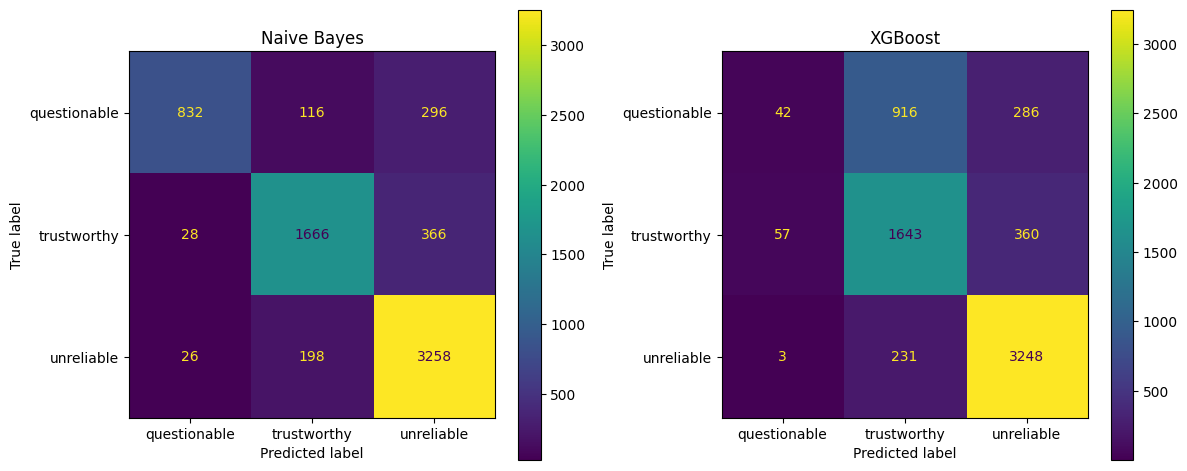

In [ ]:
plot_confusion_matrices(
    pipeline_nb,
    pipeline_xgb,
    le,
    X_test,
    y_test,
    unrel_proba_test
)

# Adding RAG to connect to an LLM

## Embedding dataset and persisting in Chroma

We will embed  store in a vector store (Chroma).

## Embedder function

In [ ]:
def docs_vectorstore(df_dataset):
    # This function will create the vector store blueprint (vector_store)
    # And the document to send there (documents)

    # We instantiate an embedding model
    embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

    # Create a Chroma vector store using the embedder 'embeddings' we created earlier
    vector_store = Chroma(
        collection_name="liar_dataset",  # Name we give our dataset
        embedding_function=embeddings,   # Embedding function (sort of embedding blueprint)
        persist_directory="./chroma_db"  # Directory where embedded copy lives.
    )

    # Bringing all columns to uniform formats to avoid semantic duplicates due to typos or punctuation
    for col in df_dataset.columns:
        df_dataset[col] = (
            df_dataset[col]
            .fillna("")
            .astype(str)
            .str.lower()
            .str.strip()
            .str.replace(r"\d+", "", regex=True) # We replace numbers by empty values
            .str.replace(r"[^\w\s]", " ", regex=True) # We replace punctuation by blank spaces, since it might separate two words.
        )

    # Applying label simplifier
    df_dataset["label"] = df_dataset["label"].apply(simplify_label)

    # Applying column cluster for "context"
    df_dataset["context"] = df_dataset["context"].apply(simplify_context)


    # Convert each dataframe row into a Langchain document
    documents = [
        Document(
            page_content=row["statement"],  # text to embed
            metadata={
                "label": row["label"],
                "speaker": row["speaker"],
                "context": row["context"]
            }
        )
        for _, row in df_dataset.iterrows()
    ]

    return vector_store, documents

We vectorize and embed the documents by batches, and store information about the last loaded batch.
This will allow us to restart from the next batch if it crashes, without starting all over again.

In [ ]:
# Only needed if embedded file is not existing yet!!!

def embedder(vector_store, documents, batch_size):                         # Make sure length of batch_size is not too big

    processed_batches = set()                                              # Stores completed batch numbers

    try:
        with open("processed_batches.pkl", "rb") as f:                     # Open previous progress file
            processed_batches = pickle.load(f)                             # Load completed batches
    except:
        pass                                                               # If file doesn't exist, start from scratch

    for i in range(0, len(documents), batch_size):                         # Loop through documents by batch
        batch_num = i // batch_size                                        # Compute current batch number

        if batch_num in processed_batches:                                 # Check if batch already processed
            continue                                                       # Skip if already done

        print(f"Starting batch {batch_num}")                               # Print batch being processed

        batch = documents[i:i+batch_size]                                  # Extract current batch
        vector_store.add_documents(batch)                                  # Embed and store batch in Chroma
        processed_batches.add(batch_num)                                   # Mark batch as completed

        with open("processed_batches.pkl", "wb") as f:                     # Save progress to disk
            pickle.dump(processed_batches, f)                              # Write completed batches

        time.sleep(3)   # after each successful batch

    return f"Completed batch {batch_num}"                                  # Confirm successful completion

In [32]:
# ONLY RUN WHEN NEEDING TO EMBED A NEW VECTOR STORE
# vector_store, documents = docs_vectorstore(df_dataset)
# embedder(vector_store, documents, 500)

In [33]:
def statement_df_retriever(vector_store, X_predict, k_similar=5, speaker=None, context=None):

    query = str(X_predict["statement"])

    chroma_filter = {}

    if speaker is not None:
        chroma_filter["speaker"] = speaker

    if context is not None:
        chroma_filter["context"] = context

    retrieved_docs = vector_store.similarity_search(
        query,
        k=k_similar,
        filter=chroma_filter if chroma_filter else None
    )

    df_retrieved = pd.DataFrame([
        {
            "speaker": doc.metadata.get("speaker"),
            "label": doc.metadata.get("label"),
            "context": doc.metadata.get("context"),
            "statement": doc.page_content
        }
        for doc in retrieved_docs
    ])

    return df_retrieved

## Accessing LLM to give information on statement

### We will call Gemini directly via Langchain commands

In the cell below, we define the parameters of the model we will interact with.

Here we will define the structure of the query to send to the LLM.

In [34]:
def prompt_creator(X_predict, final_prediction, df_retrieved, max_words=100):

    # We define main context for the query (System message)

    system_msg = """
    You are a political fact-checking assistant.
    Use the "retrieved examples" to explain the prediction.
    Do not invent facts.
    Base your reasoning on the provided examples.
    Only three labels are possible (Unreliable, Questionable, Trustworthy)
    """

    # We retrieve all information from statement to evaluate

    q_statement = X_predict["statement"]                 # Retrieve statement to evaluate
    q_speaker = X_predict["speaker"]                     # Retrieve speaker that made the statement
    q_context = X_predict["context"]                     # Retrieve context about the statement


    # We retrieve all information predicted by models about the statement

    q_prediction_nb = final_prediction["pred_nb"]        # Retrieve prediction from Naive Bayes model
    q_probas_nb = final_prediction["probas_nb"]          # Retrieve confidence from Naive Bayes model
    q_prediction_xg = final_prediction["pred_xgb"]       # Retrieve prediction from NB + XG_Boost models
    q_probas_xg = final_prediction["probas_xgb"]        # Retrieve confidence from NB + XG_Boost models


    # We retrieve top k similar statements stored in Chroma

    q_similar_st2 = "\n\n".join(
        df_retrieved.head(3).apply(
            lambda row:
            f"Label: {row['label']}\n"
            f"Speaker: {row['speaker']}\n"
            f"Context: {row['context']}\n"
            f"Statement: {row['statement']}",
            axis=1
        )
    )

    human_msg = f"""
    Statement to evaluate: {q_statement}\n
    Speaker: {q_speaker}\n
    Context: {q_context}\n\n
    Naive Bayes prediction: {q_prediction_nb}\n
    XG_Boost prediction: {q_prediction_xg}\n\n
    Retrieved similar statements from training dataset:\n
    {q_similar_st2}\n\n
    Explain in maximum {max_words} words:\n
    - What patterns appear in the retrieved examples \n
    - Possible rethorical bias
    """

    messages = [system_msg, human_msg]

    return messages

In [ ]:
def llm_query(temperature, max_tokens, messages):

    llm_model = ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",
        temperature=temperature,
        max_tokens=max_tokens
    )

    client = Client()

    response = llm_model.invoke(messages)

    return Markdown(response.text)

### Adjusting generation parameters

# Testing entire pipeline

### Preprocessing dataset

In [37]:
# In this cell, data is preprocessed and made ready for the models to be trained

# Merging LIAR dataset with POLITIFACT dataset
df_dataset = dataset_merger(df_l_train, df_l_test, df_l_val, df_pol)            # Using the merger function to merge LIAR & Politifact datasets

# Begining preprocessing
df_preproc = full_preprocessing(df_dataset)                                     # Full preprocessing of the text
df_token = tokenizer(df_preproc)                                                # Tokenizing preprocessed text dataset (convert to list of words)
df_sw = rm_stopwords(df_token)                                                  # Removing stopwords from tokenized text
df_lm = lemmatizer(df_sw)                                                       # Lemmatizing words (grouping into more generic and semantically similar versions)
df_st = df_stringifier(df_lm)                                                   # Re-converting to string for next steps

# Splitting data, training and evaluating models
X_train, X_test, y_train, y_test, ycounts = split_data(df_st)                   # Splitting data into training and testing
pipeline_nb, unrel_proba_train = train_naive_bayes(X_train, y_train)            # Training Naive Bayes model on training dataset
pipeline_xgb, le = train_xg_boost(X_train, y_train, unrel_proba_train)          # Training XG Boost model on training dataset
nb_results, unrel_proba_test = evaluate_nb(pipeline_nb, X_test, y_test)         # Evaluating  Naive Bayes model results
xgb_results = evaluate_xgb(X_test, y_test, pipeline_xgb, le, unrel_proba_test)  # Evaluating XG Boost model results

### Defining and predicting new statement

In [38]:
# Defining information to evaluate, and computing predictions from both models:

X_predict = pd.DataFrame({
    "statement": ["We will decrease taxes in our next term"],
    "speaker": ["Donald Trump"],
    "context": ["Tweet"]
})

final_prediction = liar_predict(pipeline_nb, pipeline_xgb, le, X_predict)

### Getting similar statements and reasoning from LLM

In [39]:
# Retrieving most similar statements (filtered/unfiltered) from previously created vector store in Chroma

vector_store, _ = docs_vectorstore(df_dataset)
df_retrieved = statement_df_retriever(vector_store, X_predict, 5)

# Defining prompt to ask LLM (Gemini) for explanation on retrieved statements and possible patterns for predicted score and label

messages = prompt_creator(X_predict, final_prediction, df_retrieved)
final_response = llm_query(0.7, 5000, messages)


In [40]:
pd.set_option("display.max_colwidth", None)
print(df_retrieved["statement"])


0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [41]:
final_response

The retrieved examples show political statements promising to cut or decrease taxes, like "i will keep taxes low and cut them where i can," and these are consistently labeled as 'questionable'.

The models' 'trustworthy' prediction for the statement "We will decrease taxes in our next term" suggests a potential rhetorical bias. Political promises about future tax decreases are often difficult to verify at the time of utterance and have historically been labeled 'questionable' in the training data, indicating a common pattern of unverified political rhetoric.

# Category selection

## Selecting top Speakers

In [ ]:
def top_speakers(df, n=10):
    return (
        df["speaker"]
        .value_counts()
        .head(n)
        .reset_index(name="count")
        .rename(columns={"speaker": "count", "index": "speaker"})
    )

In [ ]:
top_speakers(df_dataset, 10)

,count,count
0,facebook posts,2011
1,donald trump,1293
2,barack obama,1174
3,viral image,944
4,bloggers,717
5,hillary clinton,564
6,mitt romney,407
7,scott walker,384
8,chain email,353
9,rick perry,344


## Selecting top Contexts

In [ ]:
def top_contexts(df, n=10):
    return (
        df["context"]
        .value_counts()
        .head(n)
        .reset_index(name="count")
        .rename(columns={"context": "count", "index": "context"})
    )

In [ ]:
top_contexts(df_dataset, 10)

,count,count
0,other,17795
1,social media,5756
2,ad,3895
3,interview,1913
4,debate,931
5,tv appearance,927
6,press release,852
7,email,788
8,statement,753
9,news conference,317
